In [1]:
# @title
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import librosa
from tqdm.auto import tqdm
from pathlib import Path

import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

file_path = '/content/drive/My Drive/ribbit/anuraset'
audio_file_path = f'{file_path}/audio'

atlantic_1_file_path = f'{audio_file_path}/INCT4'
cerrado_1_file_path = f'{audio_file_path}/INCT17'
cerrado_2_file_path = f'{audio_file_path}/INCT41'
atlantic_2_file_path = f'{audio_file_path}/INCT20955'

Mounted at /content/drive


In [2]:
# @title
metadata_df = pd.read_csv(f"{file_path}/metadata.csv")

species_df = pd.read_csv(f"{file_path}/species.csv")
species_name_map = dict(zip(species_df['CODE'], species_df['SPECIES']))
family_map = dict(zip(species_df['CODE'], species_df['FAMILY']))

metadata_df.head()

cols = metadata_df.columns
species_columns = [
    'SPHSUR', 'BOABIS', 'SCIPER', 'DENNAH', 'LEPLAT', 'RHIICT', 'BOALEP', 'BOAFAB',
    'PHYCUV', 'DENMIN', 'ELABIC', 'BOAPRA', 'DENCRU', 'BOALUN', 'BOAALB', 'PHYMAR',
    'PITAZU', 'PHYSAU', 'LEPFUS', 'DENNAN', 'PHYALB', 'LEPLAB', 'SCIFUS', 'BOARAN',
    'SCIFUV', 'AMEPIC', 'LEPPOD', 'ADEDIP', 'ELAMAT', 'PHYNAT', 'LEPELE', 'RHISCI',
    'SCINAS', 'LEPNOT', 'ADEMAR', 'BOAALM', 'PHYDIS', 'RHIORN', 'LEPFLA', 'SCIRIZ',
    'DENELE', 'SCIALT'
]

# map longitude, latidude, and site name
site_mapping = {
    'INCT41': {'Latitude': -20.9699, 'Longitude': -56.5142, 'Site_Name': 'Estancia Mimosa, Mato Grosso do Sul'},
    'INCT4': {'Latitude': -24.5878, 'Longitude': -48.6289, 'Site_Name': 'Reserva Betary, São Paulo'},
    'INCT20955': {'Latitude': -28.1638, 'Longitude': -49.4729, 'Site_Name': 'Orleans, Santa Catarina'},
    'INCT17': {'Latitude': -16.9657, 'Longitude': -48.6567, 'Site_Name': 'Silvania 2, State of Goiás'}
}

metadata_df['latitude'] = metadata_df['site'].map(lambda x: site_mapping.get(x, {}).get('Latitude'))
metadata_df['longitude'] = metadata_df['site'].map(lambda x: site_mapping.get(x, {}).get('Longitude'))
metadata_df['site_name'] = metadata_df['site'].map(lambda x: site_mapping.get(x, {}).get('Site_Name'))

# add list of string with species list
metadata_df['species_present'] = metadata_df.apply(
    lambda row: list(set([sp for sp in species_columns if row[sp] == 1])),
    axis=1
)

metadata_df['calculated_species_sum'] = metadata_df[species_columns].sum(axis=1)
is_matching = (metadata_df['species_number'] == metadata_df['calculated_species_sum'])

metadata_df['species_string'] = metadata_df['species_present'].apply(
    lambda x: ', '.join(x) if len(x) > 0 else 'No species'
)

metadata_df[['fname','min_t','max_t', 'date', 'site', 'subset','species_number','calculated_species_sum']]

,fname,min_t,max_t,date,site,subset,species_number,calculated_species_sum
0,INCT20955_20190904_003000,0,3,2019-09-04 00:30:00,INCT20955,test,4,2
1,INCT20955_20190904_003000,1,4,2019-09-04 00:30:00,INCT20955,test,4,2
2,INCT20955_20190904_003000,2,5,2019-09-04 00:30:00,INCT20955,test,4,2
3,INCT20955_20190904_003000,3,6,2019-09-04 00:30:00,INCT20955,test,4,2
4,INCT20955_20190904_003000,4,7,2019-09-04 00:30:00,INCT20955,test,4,2
...,...,...,...,...,...,...,...,...
93373,INCT4_20210105_021500,53,56,2021-01-05 02:15:00,INCT4,train,0,0
93374,INCT4_20210105_021500,54,57,2021-01-05 02:15:00,INCT4,train,0,0
93375,INCT4_20210105_021500,55,58,2021-01-05 02:15:00,INCT4,train,0,0
93376,INCT4_20210105_021500,56,59,2021-01-05 02:15:00,INCT4,train,0,0


In [3]:
metadata_df.columns

Index(['sample_name', 'fname', 'min_t', 'max_t', 'site', 'date',
       'species_number', 'subset', 'SPHSUR', 'BOABIS', 'SCIPER', 'DENNAH',
       'LEPLAT', 'RHIICT', 'BOALEP', 'BOAFAB', 'PHYCUV', 'DENMIN', 'ELABIC',
       'BOAPRA', 'DENCRU', 'BOALUN', 'BOAALB', 'PHYMAR', 'PITAZU', 'PHYSAU',
       'LEPFUS', 'DENNAN', 'PHYALB', 'LEPLAB', 'SCIFUS', 'BOARAN', 'SCIFUV',
       'AMEPIC', 'LEPPOD', 'ADEDIP', 'ELAMAT', 'PHYNAT', 'LEPELE', 'RHISCI',
       'SCINAS', 'LEPNOT', 'ADEMAR', 'BOAALM', 'PHYDIS', 'RHIORN', 'LEPFLA',
       'SCIRIZ', 'DENELE', 'SCIALT', 'latitude', 'longitude', 'site_name',
       'species_present', 'calculated_species_sum', 'species_string'],
      dtype='object')

In [4]:
# @title
print(f"audios with at least one species? {len(metadata_df[metadata_df['species_present'].apply(lambda x: len(x) > 0)])}")
print(f"audios with no species? {len(metadata_df[metadata_df['species_present'].apply(lambda x: len(x) <= 0)])}")
print(f"audios with exactly one species? {len(metadata_df[metadata_df['species_present'].apply(lambda x: len(x) == 1)])}")
print(f"audios with exactly one species (dif col)? {len(metadata_df[metadata_df['calculated_species_sum']== 1])}")

print(f"unmatching species_number and calculated_species_sum {len(metadata_df[metadata_df['calculated_species_sum'] != metadata_df['species_number']])}")


audios with at least one species? 59465
audios with no species? 33913
audios with exactly one species? 19282
audios with exactly one species (dif col)? 19282
unmatching species_number and calculated_species_sum 59394


In [5]:
# @title
print("="*60)
print("Single species calls, raw numbers")
print("="*60)

single_species_df = metadata_df[metadata_df['species_present'].apply(lambda x: len(x) == 1)].copy()
print(f"len: {len(single_species_df)}")
print(f"len unique frogs: {len(single_species_df['species_string'].unique())}")
print(f"unique frogs: {single_species_df['species_string'].unique()}")

single_species_df['species'] = single_species_df['species_present'].apply(
    lambda x: x[0] if len(x) > 0 else None
)

species_counts = single_species_df['species'].value_counts()

species_analysis_df = pd.DataFrame({
    'code': species_counts.index,
    'count': species_counts.values
})

# map species names and families
species_name_map = dict(zip(species_df['CODE'], species_df['SPECIES']))
family_map = dict(zip(species_df['CODE'], species_df['FAMILY']))

species_analysis_df['species_name'] = species_analysis_df['code'].map(species_name_map)
species_analysis_df['family'] = species_analysis_df['code'].map(family_map)
species_analysis_df['meets_30_threshold'] = species_analysis_df['count'] >= 30
species_analysis_df = species_analysis_df.sort_values('count', ascending=False).reset_index(drop=True)

species_above_30_detailed = species_analysis_df[species_analysis_df['meets_30_threshold']]

print(f"\nSpecies with ≥30 samples: {len(species_analysis_df[species_analysis_df['count'] >= 30])}")
print(f"Total recordings from these species: {species_above_30_detailed['count'].sum()}")

species_above_30_detailed[['code', 'species_name', 'family', 'count']]

Single species calls, raw numbers
len: 19282
len unique frogs: 34
unique frogs: ['SCIPER' 'SPHSUR' 'DENNAH' 'BOABIS' 'LEPLAT' 'PHYCUV' 'BOAFAB' 'ELABIC'
 'DENMIN' 'BOAPRA' 'BOALEP' 'BOALUN' 'DENCRU' 'BOAALB' 'PHYMAR' 'PITAZU'
 'PHYSAU' 'LEPFUS' 'PHYALB' 'SCIFUV' 'BOARAN' 'LEPPOD' 'DENNAN' 'ADEDIP'
 'LEPLAB' 'ADEMAR' 'LEPNOT' 'PHYDIS' 'BOAALM' 'RHIORN' 'LEPFLA' 'SCIRIZ'
 'DENELE' 'SCIALT']

Species with ≥30 samples: 28
Total recordings from these species: 19247


,code,species_name,family,count
0,BOAALB,Boana albopunctata,HYLIDAE,2669
1,BOAFAB,Boana faber,HYLIDAE,2566
2,BOABIS,Boana bischoffi,HYLIDAE,2512
3,SPHSUR,Sphaenorhynchus surdus,HYLIDAE,1769
4,LEPPOD,Leptodactylus podicipinus,LEPTODACTYLIDAE,1162
5,PHYCUV,Physalaemus cuvieri,LEPTODACTYLIDAE,982
6,BOALUN,Boana lundii,HYLIDAE,850
7,PHYALB,Physalaemus albonotatus,LEPTODACTYLIDAE,799
8,PITAZU,Pithecopus azureus,HYLIDAE,773
9,DENMIN,Dendropsophus minutus,HYLIDAE,754


In [6]:
# @title
# what if i take location as a contrains? - background noise might interfer. am i biasing my model?
species_by_site = single_species_df.groupby(['species', 'site']).size().reset_index(name='count')
species_name_map = dict(zip(species_df['CODE'], species_df['SPECIES']))
family_map = dict(zip(species_df['CODE'], species_df['FAMILY']))

species_by_site['species_name'] = species_by_site['species'].map(species_name_map)
species_by_site['family'] = species_by_site['species'].map(family_map)

site_name_map = dict(zip(metadata_df['site'], metadata_df['site_name']))
species_by_site['site_name'] = species_by_site['site'].map(site_name_map)

species_by_site.head()

,species,site,count,species_name,family,site_name
0,ADEDIP,INCT17,145,Adenomera diptyx,LEPTODACTYLIDAE,"Silvania 2, State of Goiás"
1,ADEMAR,INCT4,390,Adenomera marmorata,LEPTODACTYLIDAE,"Reserva Betary, São Paulo"
2,BOAALB,INCT41,2669,Boana albopunctata,HYLIDAE,"Estancia Mimosa, Mato Grosso do Sul"
3,BOAALM,INCT4,632,Boana albomarginata,HYLIDAE,"Reserva Betary, São Paulo"
4,BOABIS,INCT20955,2512,Boana bischoffi,HYLIDAE,"Orleans, Santa Catarina"


In [7]:
# @title

print("="*60)
print("SPECIES x SITE PIVOT WITH TOTALS")
print("="*60)

species_site_detail = species_by_site.copy()
species_site_detail['site_label'] = species_site_detail.apply(
    lambda row: f"{row['site']}\n{row['site_name'].split(',')[0] if pd.notna(row['site_name']) else row['site']}",
    axis=1
)

pivot = species_site_detail.pivot_table(
    index=['family', 'species_name', 'species'],
    columns='site',
    values='count',
    fill_value=0,
    aggfunc='sum',
    margins=True,
    margins_name='Total'
)

pivot_filtered = pivot[pivot['Total'] >= 30].sort_values(by='Total', ascending=False)
totals_row = pivot_filtered.sum(axis=0)
totals_index = ('TOTAL', 'TOTAL', 'TOTAL')
pivot_filtered.loc[totals_index] = totals_row

pivot_filtered


SPECIES x SITE PIVOT WITH TOTALS


site                                                 INCT17  INCT20955  INCT4  \
family          species_name                species                             
Total                                                  4484       4516   5227   
HYLIDAE         Boana albopunctata          BOAALB        0          0      0   
                Boana faber                 BOAFAB        0         14   2552   
                Boana bischoffi             BOABIS        0       2512      0   
                Sphaenorhynchus surdus      SPHSUR        0       1769      0   
LEPTODACTYLIDAE Leptodactylus podicipinus   LEPPOD     1162          0      0   
                Physalaemus cuvieri         PHYCUV        0         10      0   
HYLIDAE         Boana lundii                BOALUN        0          0      0   
LEPTODACTYLIDAE Physalaemus albonotatus     PHYALB      799          0      0   
HYLIDAE         Pithecopus azureus          PITAZU      698          0      0   
                Dendropsophus minutus       DENMIN      732          5     17   
LEPTODACTYLIDAE Leptodactylus notoaktites   LEPNOT        0          0    718   
HYLIDAE         Boana albomarginata         BOAALM        0          0    632   
LEPTODACTYLIDAE Leptodactylus fuscus        LEPFUS      563          0      0   
HYLIDAE         Phyllomedusa distincta      PHYDIS        0          0    482   
LEPTODACTYLIDAE Adenomera marmorata         ADEMAR        0          0    390   
HYLIDAE         Dendropsophus cruzi         DENCRU        0          0      0   
LEPTODACTYLIDAE Leptodactylus latrans       LEPLAT        0         60    228   
                Physalaemus marmoratus      PHYMAR        0          0      0   
HYLIDAE         Phyllomedusa sauvagii       PHYSAU      155          0      0   
LEPTODACTYLIDAE Adenomera diptyx            ADEDIP      145          0      0   
HYLIDAE         Scinax perereca             SCIPER        0        139      0   
                Dendropsophus nanus         DENNAN      114          0      0   
                Scinax alter                SCIALT        0          0     71   
                Scinax rizibilis            SCIRIZ        0          0     55   
                Dendropsophus elegans       DENELE        0          0     54   
LEPTODACTYLIDAE Leptodactylus labyrinthicus LEPLAB       48          0      0   
HYLIDAE         Boana raniceps              BOARAN       37          0      0   
                Scinax fuscovarius          SCIFUV       31          0      0   
TOTAL           TOTAL                       TOTAL      8968       9025  10426   

site                                                 INCT41  Total  
family          species_name                species                 
Total                                                  5055  19282  
HYLIDAE         Boana albopunctata          BOAALB     2669   2669  
                Boana faber                 BOAFAB        0   2566  
                Boana bischoffi             BOABIS        0   2512  
                Sphaenorhynchus surdus      SPHSUR        0   1769  
LEPTODACTYLIDAE Leptodactylus podicipinus   LEPPOD        0   1162  
                Physalaemus cuvieri         PHYCUV      972    982  
HYLIDAE         Boana lundii                BOALUN      850    850  
LEPTODACTYLIDAE Physalaemus albonotatus     PHYALB        0    799  
HYLIDAE         Pithecopus azureus          PITAZU       75    773  
                Dendropsophus minutus       DENMIN        0    754  
LEPTODACTYLIDAE Leptodactylus notoaktites   LEPNOT        0    718  
HYLIDAE         Boana albomarginata         BOAALM        0    632  
LEPTODACTYLIDAE Leptodactylus fuscus        LEPFUS        0    563  
HYLIDAE         Phyllomedusa distincta      PHYDIS        0    482  
LEPTODACTYLIDAE Adenomera marmorata         ADEMAR        0    390  
HYLIDAE         Dendropsophus cruzi         DENCRU      303    303  
LEPTODACTYLIDAE Leptodactylus latrans       LEPLAT        0    288  
                Physalaemus

In [8]:
# @title
# ============================================================================
# does site affect low-count?
# ============================================================================

species_below_100 = species_analysis_df[
    (species_analysis_df['count'] >= 30) & (species_analysis_df['count'] < 300)
].copy()

print(f"\nSpecies with <30 samples: {len(species_below_100)}")
print(f"\nBreakdown by count:")

count_ranges = [(30, 50), (50, 100), (100, 200), (200, 300)]
for low, high in count_ranges:
    in_range = species_below_100[(species_below_100['count'] >= low) & (species_below_100['count'] <= high)]
    print(f"  {low}-{high} samples: {len(in_range)} species")

low_count_codes = species_below_100['code'].tolist()
low_count_site_dist = species_by_site[species_by_site['species'].isin(low_count_codes)]

print("\nLow-count species distribution across sites:")
print("-"*80)

for species_code in low_count_codes:
    species_data = low_count_site_dist[low_count_site_dist['species'] == species_code]

    if len(species_data) > 0:
        species_name = species_data.iloc[0]['species_name']
        total = species_data['count'].sum()
        n_sites = len(species_data)

        site_details = []
        for _, row in species_data.iterrows():
            site_short = row['site_name'].split(',')[0] if pd.notna(row['site_name']) else row['site']
            site_details.append(f"{row['site']}({row['count']})")

        sites_str = ", ".join(site_details)
        print(f"  {species_name} ({species_code}): {total} total, {n_sites} site(s) - {sites_str}")


Species with <30 samples: 12

Breakdown by count:
  30-50 samples: 3 species
  50-100 samples: 3 species
  100-200 samples: 5 species
  200-300 samples: 1 species

Low-count species distribution across sites:
--------------------------------------------------------------------------------
  Leptodactylus latrans (LEPLAT): 288 total, 2 site(s) - INCT20955(60), INCT4(228)
  Physalaemus marmoratus (PHYMAR): 186 total, 1 site(s) - INCT41(186)
  Phyllomedusa sauvagii (PHYSAU): 155 total, 1 site(s) - INCT17(155)
  Adenomera diptyx (ADEDIP): 145 total, 1 site(s) - INCT17(145)
  Scinax perereca (SCIPER): 139 total, 1 site(s) - INCT20955(139)
  Dendropsophus nanus (DENNAN): 114 total, 1 site(s) - INCT17(114)
  Scinax alter (SCIALT): 71 total, 1 site(s) - INCT4(71)
  Scinax rizibilis (SCIRIZ): 55 total, 1 site(s) - INCT4(55)
  Dendropsophus elegans (DENELE): 54 total, 1 site(s) - INCT4(54)
  Leptodactylus labyrinthicus (LEPLAB): 48 total, 1 site(s) - INCT17(48)
  Boana raniceps (BOARAN): 37 tot

In [9]:
# @title
# ============================================================================
# SPECIES APPEARING AT MULTIPLE SITES
# ============================================================================

print("="*60)
print("MULTI-SITE SPECIES ANALYSIS")
print("="*60)

species_site_count = species_by_site.groupby('species').agg({
    'site': lambda x: list(x.unique()),
    'count': 'sum',
    'species_name': 'first',
    'family': 'first'
})

species_site_count['n_sites'] = species_site_count['site'].apply(len)
species_site_count = species_site_count.sort_values('n_sites', ascending=False)

print(f"\nTotal unique species: {len(species_site_count)}")
print(f"Species at 1 site: {(species_site_count['n_sites'] == 1).sum()}")
print(f"Species at 2 sites: {(species_site_count['n_sites'] == 2).sum()}")
print(f"Species at 3 sites: {(species_site_count['n_sites'] == 3).sum()}")
print(f"Species at 4 sites: {(species_site_count['n_sites'] == 4).sum()}")

multi_site_species = species_site_count[species_site_count['n_sites'] > 1]

for species_code, row in multi_site_species.iterrows():
    sites_list = ', '.join(row['site'])
    print(f"{row['species_name']} ({species_code}):")
    print(f"  Sites: {sites_list} ({row['n_sites']} sites)")
    print(f"  Total samples: {row['count']}")

    species_detail = species_by_site[species_by_site['species'] == species_code]
    for _, detail in species_detail.iterrows():
        site_name_short = detail['site_name'].split(',')[0] if pd.notna(detail['site_name']) else detail['site']
        print(f"    - {detail['site']} ({site_name_short}): {detail['count']} samples")
    print()

print("="*60)
print("MULTI-SITE SPECIES WITH ≥30 SAMPLES")
print("="*60)

multi_site_above_30 = multi_site_species[multi_site_species['count'] >= 30]

print(f"\nNumber of species: {len(multi_site_above_30)}")
print(f"Total samples: {multi_site_above_30['count'].sum()}\n")

if len(multi_site_above_30) > 0:
    print("These species are IDEAL for cross-site experiments:")
    print("-"*80)

    for species_code, row in multi_site_above_30.iterrows():
        sites_list = ', '.join(row['site'])
        print(f"\n{row['species_name']} ({species_code}):")
        print(f"  Sites: {sites_list}")
        print(f"  Total: {row['count']} samples")

        species_detail = species_by_site[species_by_site['species'] == species_code]
        for _, detail in species_detail.iterrows():
            site_name_short = detail['site_name'].split(',')[0] if pd.notna(detail['site_name']) else detail['site']
            print(f"    - {detail['site']}: {detail['count']} samples")
else:
    print("Cross-site experiments will not be possible")


MULTI-SITE SPECIES ANALYSIS

Total unique species: 34
Species at 1 site: 29
Species at 2 sites: 4
Species at 3 sites: 1
Species at 4 sites: 0
Dendropsophus minutus (DENMIN):
  Sites: INCT17, INCT20955, INCT4 (3 sites)
  Total samples: 754
    - INCT17 (Silvania 2): 732 samples
    - INCT20955 (Orleans): 5 samples
    - INCT4 (Reserva Betary): 17 samples

Boana faber (BOAFAB):
  Sites: INCT20955, INCT4 (2 sites)
  Total samples: 2566
    - INCT20955 (Orleans): 14 samples
    - INCT4 (Reserva Betary): 2552 samples

Pithecopus azureus (PITAZU):
  Sites: INCT17, INCT41 (2 sites)
  Total samples: 773
    - INCT17 (Silvania 2): 698 samples
    - INCT41 (Estancia Mimosa): 75 samples

Leptodactylus latrans (LEPLAT):
  Sites: INCT20955, INCT4 (2 sites)
  Total samples: 288
    - INCT20955 (Orleans): 60 samples
    - INCT4 (Reserva Betary): 228 samples

Physalaemus cuvieri (PHYCUV):
  Sites: INCT20955, INCT41 (2 sites)
  Total samples: 982
    - INCT20955 (Orleans): 10 samples
    - INCT41 (Esta

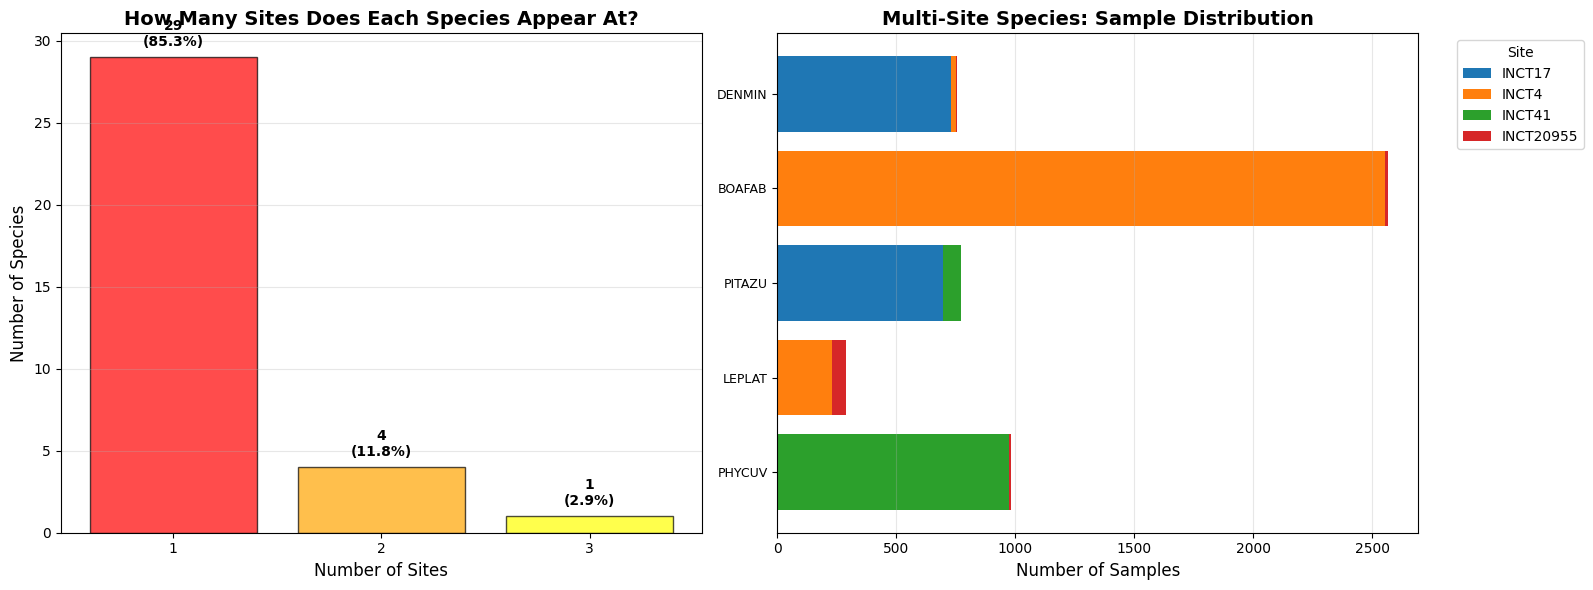

In [10]:
# @title
# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax1 = axes[0]
site_coverage_dist = species_site_count['n_sites'].value_counts().sort_index()
colors = ['red', 'orange', 'yellow', 'green']
ax1.bar(site_coverage_dist.index, site_coverage_dist.values,
        color=colors[:len(site_coverage_dist)], edgecolor='black', alpha=0.7)
ax1.set_xlabel('Number of Sites', fontsize=12)
ax1.set_ylabel('Number of Species', fontsize=12)
ax1.set_title('How Many Sites Does Each Species Appear At?', fontsize=14, fontweight='bold')
ax1.set_xticks(site_coverage_dist.index)
ax1.grid(axis='y', alpha=0.3)

for i, (n_sites, count) in enumerate(site_coverage_dist.items()):
    pct = count / len(species_site_count) * 100
    ax1.text(n_sites, count + 0.5, f'{count}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = axes[1]
if len(multi_site_species) > 0:
    multi_site_codes = multi_site_species.index.tolist()
    site_names = species_by_site['site'].unique()
    bottom = np.zeros(len(multi_site_codes))

    for site in site_names:
        site_counts = []
        for sp_code in multi_site_codes:
            sp_data = species_by_site[(species_by_site['species'] == sp_code) &
                                     (species_by_site['site'] == site)]
            count = sp_data['count'].values[0] if len(sp_data) > 0 else 0
            site_counts.append(count)

        ax2.barh(range(len(multi_site_codes)), site_counts, left=bottom, label=site)
        bottom += np.array(site_counts)

    ax2.set_yticks(range(len(multi_site_codes)))
    ax2.set_yticklabels(multi_site_codes, fontsize=9)
    ax2.set_xlabel('Number of Samples', fontsize=12)
    ax2.set_title('Multi-Site Species: Sample Distribution', fontsize=14, fontweight='bold')
    ax2.legend(title='Site', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(axis='x', alpha=0.3)
    ax2.invert_yaxis()
else:
    ax2.text(0.5, 0.5, 'No multi-site species found',
             ha='center', va='center', fontsize=14)
    ax2.set_title('Multi-Site Species Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('multi_site_species_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
#species_counts = single_species_df['species'].value_counts()

#species_analysis_df = pd.DataFrame({
#    'code': species_counts.index,
#    'count': species_counts.values
#})

# map species names and families
#species_name_map = dict(zip(species_df['CODE'], species_df['SPECIES']))
#family_map = dict(zip(species_df['CODE'], species_df['FAMILY']))

#species_analysis_df['species_name'] = species_analysis_df['code'].map(species_name_map)
#species_analysis_df['family'] = species_analysis_df['code'].map(family_map)
#species_analysis_df['meets_30_threshold'] = species_analysis_df['count'] >= 30
#species_analysis_df = species_analysis_df.sort_values('count', ascending=False).reset_index(drop=True)

#species_above_30_detailed = species_analysis_df[species_analysis_df['meets_30_threshold']]

#print(f"\nSpecies with ≥30 samples: {len(species_analysis_df[species_analysis_df['count'] >= 30])}")
#print(f"Total recordings from these species: {species_above_30_detailed['count'].sum()}")

#species_above_30_detailed[['code', 'species_name', 'family', 'count']]


metadata_df.head(1).T

,0
sample_name,SAMPLE_00000.wav
fname,INCT20955_20190904_003000
min_t,0
max_t,3
site,INCT20955
date,2019-09-04 00:30:00
species_number,4
subset,test
SPHSUR,1
BOABIS,1


# Extracting audio features to this samples that have only one call...

In [12]:
# @title
import librosa
import numpy as np
from pathlib import Path

def extract_anura_features(
    audio_root,
    site,
    fname,
    sr=None,
    n_mels=64,
    n_mfcc=13,
    hop_length=256,
    n_fft=512
):
    """
    Load an anuran audio file and extract acoustic + background noise features
    suitable for EDA and unsupervised clustering.
    """

    path = Path(audio_root) / site / fname
    y, sr = librosa.load(path, sr=sr, mono=True)

    # --------------------
    # Basic properties
    # --------------------
    duration = float(len(y) / sr)

    # --------------------
    # Energy / loudness
    # --------------------
    rms_frame = librosa.feature.rms(y=y)[0]
    rms_mean = float(np.mean(rms_frame))
    rms_std = float(np.std(rms_frame))
    rms_cv = float(rms_std / (rms_mean + 1e-8))  # variability = call vs noise

    # --------------------
    # Spectral features
    # --------------------
    spectral_centroid = float(
        librosa.feature.spectral_centroid(y=y, sr=sr).mean()
    )

    spectral_bandwidth = float(
        librosa.feature.spectral_bandwidth(y=y, sr=sr).mean()
    )

    spectral_rolloff = float(
        librosa.feature.spectral_rolloff(
            y=y, sr=sr, roll_percent=0.85
        ).mean()
    )

    spectral_flatness = float(
        librosa.feature.spectral_flatness(y=y).mean()
    )

    # --------------------
    # Pitch (very important for frogs)
    # --------------------
    try:
        f0 = librosa.yin(y, fmin=80, fmax=5000, sr=sr)
        f0_mean = float(np.nanmean(f0))
        f0_std = float(np.nanstd(f0))
    except Exception:
        f0_mean, f0_std = np.nan, np.nan

    # --------------------
    # MFCCs (call shape / timbre)
    # --------------------
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length
    )
    mfcc_means = mfcc.mean(axis=1)

    # --------------------
    # Mel spectral energy
    # --------------------
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel)
    mel_energy_mean = float(mel_db.mean())

    # --------------------
    # Background noise indicators
    # --------------------

    # Spectral entropy (disorder / noisiness)
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
    S_norm = S / (np.sum(S, axis=0, keepdims=True) + 1e-10)
    spectral_entropy = float(
        -np.mean(np.sum(S_norm * np.log2(S_norm + 1e-10), axis=0))
    )

    # Low-frequency noise ratio (wind / water / rumble)
    low_freq_energy = mel_db[:10, :].mean()    # ~0–500 Hz
    high_freq_energy = mel_db[10:, :].mean()
    low_freq_ratio = float(
        low_freq_energy / (high_freq_energy + 1e-8)
    )

    # Silence ratio (how much of the file is near silence)
    silence_ratio = float(
        np.mean(rms_frame < np.percentile(rms_frame, 10))
    )

    # --------------------
    # Assemble output
    # --------------------
    features = {
        "site": site,
        "fname": fname,
        "path": str(path),
        "sr": int(sr),
        "duration": duration,

        # Energy
        "rms": rms_mean,
        "rms_std": rms_std,
        "rms_cv": rms_cv,

        # Spectral
        "spectral_centroid": spectral_centroid,
        "spectral_bandwidth": spectral_bandwidth,
        "spectral_rolloff": spectral_rolloff,
        "spectral_flatness": spectral_flatness,

        # Pitch
        "f0_mean": f0_mean,
        "f0_std": f0_std,

        # Noise / environment
        "spectral_entropy": spectral_entropy,
        "low_freq_ratio": low_freq_ratio,
        "silence_ratio": silence_ratio,

        # Broad energy
        "mel_energy_mean": mel_energy_mean,
    }

    # Add MFCCs
    for i, val in enumerate(mfcc_means, start=1):
        features[f"mfcc_{i}"] = float(val)

    return features


In [13]:
# @title
audio_root = "/content/drive/My Drive/ribbit/anuraset/audio"

row = single_species_df[single_species_df['site'] == 'INCT4'].iloc[0]
#function testing
valid_fname = f"{row['fname']}_{row['min_t']}_{row['max_t']}.wav"
print(valid_fname)

row = extract_anura_features(
    audio_root=audio_root,
    site="INCT4",
    fname=f"{valid_fname}"
)

row1 = single_species_df[single_species_df['site'] == 'INCT4'].iloc[1]
#function testing
valid_fname = f"{row1['fname']}_{row1['min_t']}_{row1['max_t']}.wav"
print(valid_fname)

row1 = extract_anura_features(
    audio_root=audio_root,
    site="INCT4",
    fname=f"{valid_fname}"
)
print(row)
print(row1)

INCT4_20191023_181500_0_3.wav
INCT4_20191023_181500_1_4.wav
{'site': 'INCT4', 'fname': 'INCT4_20191023_181500_0_3.wav', 'path': '/content/drive/My Drive/ribbit/anuraset/audio/INCT4/INCT4_20191023_181500_0_3.wav', 'sr': 22050, 'duration': 3.0, 'rms': 0.1520605981349945, 'rms_std': 0.04572318494319916, 'rms_cv': 0.3006905305982177, 'spectral_centroid': 1927.9547660738897, 'spectral_bandwidth': 2294.2197742490034, 'spectral_rolloff': 4716.102764423077, 'spectral_flatness': 0.0033609706442803144, 'f0_mean': 3325.1026366252067, 'f0_std': 2323.312609361676, 'spectral_entropy': 5.7567830085754395, 'low_freq_ratio': 0.47696352005004883, 'silence_ratio': 0.1, 'mel_energy_mean': -23.59282875061035, 'mfcc_1': -276.0740966796875, 'mfcc_2': 93.41654968261719, 'mfcc_3': -14.865004539489746, 'mfcc_4': 34.16033935546875, 'mfcc_5': -16.38729476928711, 'mfcc_6': 24.453920364379883, 'mfcc_7': -11.38015079498291, 'mfcc_8': 15.715758323669434, 'mfcc_9': 8.080775260925293, 'mfcc_10': 15.408361434936523, 'mf

In [18]:
single_species_df[['species','fname','min_t','max_t','site','date']].head()

,species,fname,min_t,max_t,site,date
58,SCIPER,INCT20955_20190909_050000,0,3,INCT20955,2019-09-09 05:00:00
88,SCIPER,INCT20955_20190909_050000,30,33,INCT20955,2019-09-09 05:00:00
95,SCIPER,INCT20955_20190909_050000,37,40,INCT20955,2019-09-09 05:00:00
96,SCIPER,INCT20955_20190909_050000,38,41,INCT20955,2019-09-09 05:00:00
97,SCIPER,INCT20955_20190909_050000,39,42,INCT20955,2019-09-09 05:00:00


In [24]:
import pandas as pd
import os

single_species_df['date'] = pd.to_datetime(single_species_df['date'])

def determine_season(dt):
    month = dt.month
    if 9 <= month <= 12:
        return 1
    else:
        return 0

single_species_df['is_wet_season'] = single_species_df['date'].apply(determine_season)

single_species_df['filename'] = single_species_df.apply(
    lambda row: f"{row['fname']}_{int(float(row['min_t']))}_{int(float(row['max_t']))}.wav",
    axis=1
)

export_path = '/content/drive/MyDrive/ribbit/chromadb'
os.makedirs(export_path, exist_ok=True)

file_full_path = os.path.join(export_path, 'singlespecies.csv')
single_species_df[['species', 'fname', 'min_t', 'max_t', 'filename', 'date', 'is_wet_season', 'subset', 'latitude', 'longitude', 'site', 'site_name']].to_csv(file_full_path, index=False)

print(f"Transformation complete!")
print(f"File saved to: {file_full_path}")

single_species_df[['species', 'fname', 'min_t', 'max_t', 'filename', 'date', 'is_wet_season', 'subset', 'latitude', 'longitude', 'site', 'site_name']].head()

Transformation complete!
File saved to: /content/drive/MyDrive/ribbit/chromadb/singlespecies.csv


,species,fname,min_t,max_t,filename,date,is_wet_season,subset,latitude,longitude,site,site_name
58,SCIPER,INCT20955_20190909_050000,0,3,INCT20955_20190909_050000_0_3.wav,2019-09-09 05:00:00,1,train,-28.1638,-49.4729,INCT20955,"Orleans, Santa Catarina"
88,SCIPER,INCT20955_20190909_050000,30,33,INCT20955_20190909_050000_30_33.wav,2019-09-09 05:00:00,1,train,-28.1638,-49.4729,INCT20955,"Orleans, Santa Catarina"
95,SCIPER,INCT20955_20190909_050000,37,40,INCT20955_20190909_050000_37_40.wav,2019-09-09 05:00:00,1,train,-28.1638,-49.4729,INCT20955,"Orleans, Santa Catarina"
96,SCIPER,INCT20955_20190909_050000,38,41,INCT20955_20190909_050000_38_41.wav,2019-09-09 05:00:00,1,train,-28.1638,-49.4729,INCT20955,"Orleans, Santa Catarina"
97,SCIPER,INCT20955_20190909_050000,39,42,INCT20955_20190909_050000_39_42.wav,2019-09-09 05:00:00,1,train,-28.1638,-49.4729,INCT20955,"Orleans, Santa Catarina"


In [21]:
single_species_df.columns

Index(['sample_name', 'fname', 'min_t', 'max_t', 'site', 'date',
       'species_number', 'subset', 'SPHSUR', 'BOABIS', 'SCIPER', 'DENNAH',
       'LEPLAT', 'RHIICT', 'BOALEP', 'BOAFAB', 'PHYCUV', 'DENMIN', 'ELABIC',
       'BOAPRA', 'DENCRU', 'BOALUN', 'BOAALB', 'PHYMAR', 'PITAZU', 'PHYSAU',
       'LEPFUS', 'DENNAN', 'PHYALB', 'LEPLAB', 'SCIFUS', 'BOARAN', 'SCIFUV',
       'AMEPIC', 'LEPPOD', 'ADEDIP', 'ELAMAT', 'PHYNAT', 'LEPELE', 'RHISCI',
       'SCINAS', 'LEPNOT', 'ADEMAR', 'BOAALM', 'PHYDIS', 'RHIORN', 'LEPFLA',
       'SCIRIZ', 'DENELE', 'SCIALT', 'latitude', 'longitude', 'site_name',
       'species_present', 'calculated_species_sum', 'species_string',
       'species', 'is_wet_season', 'filename'],
      dtype='object')

In [14]:
# @title
from joblib import Parallel, delayed
from tqdm.auto import tqdm

def process_row(row):
    return extract_anura_features(
        audio_root=audio_root,
        site=row['site'],
        fname=f"{row['fname']}_{row['min_t']}_{row['max_t']}.wav"
    )

n_jobs = 2 # 2 cores

results = Parallel(n_jobs=n_jobs)(
    delayed(process_row)(row)
    for _, row in tqdm(single_species_df.iterrows(),
                       total=len(single_species_df))
)

audio_features_df = pd.DataFrame(results)



  0%|          | 0/19282 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# @title
output_path = "/content/drive/My Drive/ribbit/anuraset/audio/anuraset_onecall_audiofeatures.csv"
audio_features_df.to_csv(output_path, mode="a", header=False, index=False)

#in case it dies...
parellel approch, it was not needed but.


In [ ]:
# @title
# parallel and chunked

import os
import pandas as pd
from joblib import Parallel, delayed
from tqdm.auto import tqdm

def process_row(row):
    return extract_anura_features(
        audio_root=audio_root,
        site=row['site'],
        fname=f"{row['fname']}_{row['min_t']}_{row['max_t']}.wav"
    )

output_path = "/content/drive/My Drive/ribbit/anuraset/audio/anuraset_onecall_audiofeatures.csv"

if os.path.exists(output_path):
    existing_df = pd.read_csv(output_path)
    start_idx = len(existing_df)
    print(f"Resuming from row {start_idx}")
else:
    start_idx = 0
    print("Starting from scratch")

# chunked job
chunk_size = 500
n_jobs = 2

total_rows = len(single_species_df)

for i in range(start_idx, total_rows, chunk_size):

    print(f"\nProcessing rows {i} to {min(i+chunk_size, total_rows)}")

    chunk = single_species_df.iloc[i:i+chunk_size]

    results = Parallel(n_jobs=n_jobs)(
        delayed(process_row)(row)
        for _, row in tqdm(chunk.iterrows(),
                           total=len(chunk))
    )

    chunk_df = pd.DataFrame(results)

    if os.path.exists(output_path):
        chunk_df.to_csv(output_path, mode="a", header=False, index=False)
    else:
        chunk_df.to_csv(output_path, index=False)

# Audio Features on 1 call per species

In [ ]:
# @title
single_species_df['audio_fname_key'] = single_species_df.apply(
    lambda row: f"{row['fname']}_{row['min_t']}_{row['max_t']}.wav",
    axis=1
)

features_df = pd.merge(
    single_species_df,
    audio_features_df,
    left_on='audio_fname_key',
    right_on='fname',
    how='left'

)
#print(features_df.columns)
#print(features_df.columns)
#print(features_df['calculated_species_sum'].unique())


In [ ]:
# @title
# features_df[['sample_name', 'fname_x', 'min_t', 'max_t', 'site_x', 'date',
#        'species_number', 'subset','latitude', 'longitude', 'site_name',
#        'species_present', 'calculated_species_sum', 'species_string',
#        'species', 'audio_fname_key', 'site_y', 'fname_y', 'path']]

In [ ]:
# @title

acoustic_cols = [
    'rms', 'rms_std', 'rms_cv',
    'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff',
    'spectral_flatness', 'f0_mean', 'f0_std',
    'spectral_entropy', 'low_freq_ratio', 'silence_ratio',
    'mel_energy_mean'
] + [f'mfcc_{i}' for i in range(1, 14)]

df[acoustic_cols].describe().T

In [ ]:
# @title
if 'site_x' in features_df.columns:
    features_df['site'] = features_df['site_x']
    features_df['fname'] = features_df['fname_x']

acoustic_features = [
    'rms', 'rms_std', 'rms_cv',
    'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'spectral_flatness',
    'f0_mean', 'f0_std'
]

noise_features = [
    'spectral_entropy', 'low_freq_ratio', 'silence_ratio'
]

mfcc_features = [f'mfcc_{i}' for i in range(1, 14)]

all_features = acoustic_features + noise_features + mfcc_features

single_species_features = features_df[features_df['calculated_species_sum'] == 1].copy()

species_counts = single_species_features['species'].value_counts()
species_above_30 = species_counts[species_counts >= 30].index.tolist()
df_filtered = single_species_features[single_species_features['species'].isin(species_above_30)]

species_stats = df_filtered.groupby('species')[acoustic_features].agg(['mean', 'std'])

# ============================================================================
# CREATE DATAFRAMES FOR SPECIES STATISTICS
# ============================================================================

# 1. Species feature statistics (mean ± std for all acoustic features)
species_stats_list = []

for sp in species_above_30:
    sp_data = df_filtered[df_filtered['species'] == sp]
    n_samples = len(sp_data)

    row = {'species': sp, 'n_samples': n_samples}

    for feature in acoustic_features:
        row[f'{feature}_mean'] = sp_data[feature].mean()
        row[f'{feature}_std'] = sp_data[feature].std()

    species_stats_list.append(row)

species_stats_df = pd.DataFrame(species_stats_list)

species_name_map = dict(zip(species_df['CODE'], species_df['SPECIES']))
family_map = dict(zip(species_df['CODE'], species_df['FAMILY']))

species_stats_df['species_name'] = species_stats_df['species'].map(species_name_map)
species_stats_df['family'] = species_stats_df['species'].map(family_map)

species_stats_df = species_stats_df.sort_values('n_samples', ascending=False).reset_index(drop=True)

print("="*60)
print("SPECIES ACOUSTIC FEATURES STATISTICS")
print("="*60)
print(f"\nDataFrame shape: {species_stats_df.shape}")
print(f"Species: {len(species_stats_df)}")
print("\nPreview:")
display(species_stats_df[['species_name','species', 'n_samples', 'f0_mean_mean', 'f0_mean_std',
                          'spectral_centroid_mean', 'spectral_centroid_std',
                          'rms_mean', 'rms_std']].head(28))

species_stats_df.to_csv('species_acoustic_stats.csv', index=False)
print(f"\n✓ Saved to: species_acoustic_stats.csv")




In [ ]:
# @title
# ============================================================================
# 2. Compact summary table (key features only)
# ============================================================================

key_features = ['f0_mean', 'spectral_centroid', 'rms', 'spectral_bandwidth', 'rms_cv']
compact_stats_list = []

for sp in species_above_30:
    sp_data = df_filtered[df_filtered['species'] == sp]

    row = {
        'species_name': species_name_map[sp],
        'family': family_map[sp],
        'species': sp,
        'n_samples': len(sp_data)
    }

    for feature in key_features:
        mean_val = sp_data[feature].mean()
        std_val = sp_data[feature].std()
        row[feature] = f"{mean_val:.2f} ± {std_val:.2f}"

    compact_stats_list.append(row)

compact_stats_df = pd.DataFrame(compact_stats_list)
compact_stats_df = compact_stats_df.sort_values('n_samples', ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("COMPACT SUMMARY (Key Features)")
print("="*60)
display(compact_stats_df.head(28))

compact_stats_df.to_csv('species_acoustic_stats_compact.csv', index=False)
print(f"\n✓ Saved to: species_acoustic_stats_compact.csv")


In [ ]:
# @title

# ============================================================================
# ANOVA table
# ============================================================================

anova_results = []

for feature in acoustic_features + noise_features:
    groups = [df_filtered[df_filtered['species'] == sp][feature].dropna()
              for sp in species_above_30]
    groups = [g for g in groups if len(g) > 0]

    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)

        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'ns'

        anova_results.append({
            'feature': feature,
            'F_statistic': f_stat,
            'p_value': p_value,
            'significance': significance,
            'differentiates_species': p_value < 0.05
        })

anova_df = pd.DataFrame(anova_results)
anova_df = anova_df.sort_values('F_statistic', ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("ANOVA RESULTS: Between-Species Differentiation")
print("="*60)
print("\nLegend: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
display(anova_df)

anova_df.to_csv('anova_species_differentiation.csv', index=False)
print(f"\n✓ Saved to: anova_species_differentiation.csv")


In [ ]:
# @title

# ============================================================================
# 4. Species pairwise comparison (for top features)
# ============================================================================

pivot_features = ['f0_mean', 'spectral_centroid', 'spectral_bandwidth', 'rms']
species_pivot_list = []

for sp in species_above_30:
    sp_data = df_filtered[df_filtered['species'] == sp]

    row = {'species': sp,
           'species_name': species_name_map[sp],
           'family': family_map[sp],
           }
    for feature in pivot_features:
        row[feature] = sp_data[feature].mean()

    species_pivot_list.append(row)

species_pivot_df = pd.DataFrame(species_pivot_list)
species_pivot_df = species_pivot_df.sort_values('f0_mean', ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("SPECIES RANKED BY PITCH (f0_mean)")
print("="*60)
display(species_pivot_df.head(28))

species_pivot_df.to_csv('species_ranked_by_features.csv', index=False)
print(f"\n✓ Saved to: species_ranked_by_features.csv")

In [ ]:
# @title
species_stats_df = pd.read_csv('species_acoustic_stats.csv')
anova_df = pd.read_csv('anova_species_differentiation.csv')
species_pivot_df = pd.read_csv('species_ranked_by_features.csv')

print("="*80)
print("ACOUSTIC FEATURES ANALYSIS - KEY FINDINGS")
print("="*80)

# ============================================================================
# 2. SPECIES DIFFERENTIATION POWER
# ============================================================================

print("\n" + "="*80)
print("1. BETWEEN-SPECIES DIFFERENTIATION")
print("="*80)

# All features are highly significant!
significant_features = anova_df[anova_df['differentiates_species'] == True]
print(f"\n ALL {len(significant_features)} features show HIGHLY SIGNIFICANT species differences!")
print(f"  (All p-values < 0.001)")

# Rank features by discriminative power
print("\nTop 5 most discriminative features (by F-statistic):")
print("-"*80)
top_features = anova_df.head(5)
for idx, row in top_features.iterrows():
    print(f"  {idx+1}. {row['feature']}: F={row['F_statistic']:.1f} {row['significance']}")

print("\nINTERPRETATION:")
print("  ✓ Species are HIGHLY distinguishable by acoustic features")
print("  ✓ f0_mean (pitch) is the STRONGEST differentiator (F=901)")
print("  ✓ Spectral features (bandwidth, centroid) also very strong")
print("  ✓ Even background noise features (spectral_entropy, low_freq_ratio) differentiate species")

# ============================================================================
# 3. PITCH (F0) ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("2. PITCH (F0) ANALYSIS - Most Important Feature")
print("="*80)

# Extract pitch statistics
pitch_stats = species_pivot_df[['species', 'f0_mean']].copy()
pitch_stats = pitch_stats.sort_values('f0_mean', ascending=False)

print("\nPitch range across species:")
print(f"  Highest: {pitch_stats.iloc[0]['species']} = {pitch_stats.iloc[0]['f0_mean']:.0f} Hz")
print(f"  Lowest: {pitch_stats.iloc[-1]['species']} = {pitch_stats.iloc[-1]['f0_mean']:.0f} Hz")
print(f"  Range: {pitch_stats.iloc[0]['f0_mean'] - pitch_stats.iloc[-1]['f0_mean']:.0f} Hz")
print(f"  Ratio: {pitch_stats.iloc[0]['f0_mean'] / pitch_stats.iloc[-1]['f0_mean']:.1f}x difference")

# Group by pitch ranges
print("\nSpecies grouped by pitch:")
print("-"*80)

high_pitch = pitch_stats[pitch_stats['f0_mean'] > 4500]
mid_pitch = pitch_stats[(pitch_stats['f0_mean'] >= 2500) & (pitch_stats['f0_mean'] <= 4500)]
low_pitch = pitch_stats[pitch_stats['f0_mean'] < 2500]

print(f"  High-pitched (>4500 Hz): {len(high_pitch)} species")
print(f"    {', '.join(high_pitch['species'].tolist())}")
print(f"\n  Mid-pitched (2500-4500 Hz): {len(mid_pitch)} species")
print(f"    {', '.join(mid_pitch['species'].head(10).tolist())}...")
print(f"\n  Low-pitched (<2500 Hz): {len(low_pitch)} species")
print(f"    {', '.join(low_pitch['species'].tolist())}")

# ============================================================================
# 4. WITHIN-SPECIES CONSISTENCY
# ============================================================================

print("\n" + "="*80)
print("3. WITHIN-SPECIES CONSISTENCY")
print("="*80)

# Calculate coefficient of variation for pitch
consistency_analysis = []
for idx, row in species_stats_df.iterrows():
    cv_f0 = (row['f0_mean_std'] / row['f0_mean_mean']) * 100
    cv_centroid = (row['spectral_centroid_std'] / row['spectral_centroid_mean']) * 100
    cv_rms = (row['rms_std'] / row['rms_mean']) * 100

    consistency_analysis.append({
        'species': row['species'],
        'n_samples': row['n_samples'],
        'cv_f0': cv_f0,
        'cv_centroid': cv_centroid,
        'cv_rms': cv_rms,
        'mean_cv': (cv_f0 + cv_centroid + cv_rms) / 3
    })

consistency_df = pd.DataFrame(consistency_analysis)
consistency_df = consistency_df.sort_values('mean_cv').reset_index(drop=True)

print("\nMost consistent species (low CV = reliable calls):")
print("-"*80)
print(consistency_df[['species', 'cv_f0', 'cv_centroid', 'mean_cv']].head(10).to_string(index=False))

print("\nLeast consistent species (high CV = variable calls):")
print("-"*80)
print(consistency_df[['species', 'cv_f0', 'cv_centroid', 'mean_cv']].tail(5).to_string(index=False))

# Overall consistency
mean_cv_all = consistency_df['mean_cv'].mean()
print(f"\n💡 INTERPRETATION:")
print(f"  Mean CV across all species: {mean_cv_all:.1f}%")
if mean_cv_all < 30:
    print(f"  ✓ LOW variation - species have CONSISTENT calls")
    print(f"  → Good for clustering!")
elif mean_cv_all < 50:
    print(f"  ⚠️ MODERATE variation - some within-species variability")
    print(f"  → Clustering feasible but may need more samples")
else:
    print(f"  ❌ HIGH variation - calls are highly variable")
    print(f"  → Clustering may be challenging")

# ============================================================================
# 5. SAMPLE SIZE CONCERNS
# ============================================================================

print("\n" + "="*80)
print("4. SAMPLE SIZE DISTRIBUTION")
print("="*80)

sample_ranges = [
    ('30-99', (30, 99)),
    ('100-499', (100, 499)),
    ('500-999', (500, 999)),
    ('1000+', (1000, 100000))
]

for label, (low, high) in sample_ranges:
    in_range = species_stats_df[(species_stats_df['n_samples'] >= low) &
                                (species_stats_df['n_samples'] <= high)]
    print(f"  {label} samples: {len(in_range)} species")
    if len(in_range) > 0 and label != '1000+':
        print(f"    {', '.join(in_range['species'].tolist())}")

# Imbalance
max_samples = species_stats_df['n_samples'].max()
min_samples = species_stats_df['n_samples'].min()
imbalance_ratio = max_samples / min_samples

print(f"\n💡 CLASS IMBALANCE:")
print(f"  Most abundant: {species_stats_df.iloc[0]['species']} ({max_samples} samples)")
print(f"  Least abundant: {species_stats_df.iloc[-1]['species']} ({min_samples} samples)")
print(f"  Imbalance ratio: {imbalance_ratio:.1f}:1")

if imbalance_ratio > 50:
    print(f"  ⚠️ SEVERE imbalance - consider stratified sampling or weighting")
elif imbalance_ratio > 10:
    print(f"  ⚠️ MODERATE imbalance - be aware when evaluating")
else:
    print(f"  ✓ Manageable imbalance")

# ============================================================================
# 6. FEATURE REDUNDANCY ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("5. FEATURE REDUNDANCY")
print("="*80)

# Features ranked by importance
feature_importance = anova_df[['feature', 'F_statistic']].copy()
feature_importance['normalized_importance'] = (
    feature_importance['F_statistic'] / feature_importance['F_statistic'].sum() * 100
)

print("\nFeature importance (% of total discriminative power):")
print("-"*80)
cumulative = 0
for idx, row in feature_importance.head(8).iterrows():
    cumulative += row['normalized_importance']
    print(f"  {row['feature']}: {row['normalized_importance']:.1f}% (cumulative: {cumulative:.1f}%)")

print("\n💡 INTERPRETATION:")
top_5_importance = feature_importance.head(5)['normalized_importance'].sum()
print(f"  Top 5 features account for {top_5_importance:.1f}% of discriminative power")
print(f"  → Could potentially reduce feature set without losing much information")

# ============================================================================
# 7. RECOMMENDATIONS FOR CLUSTERING
# ============================================================================

print("\n" + "="*80)
print("RECOMMENDATIONS FOR CLUSTERING EXPERIMENTS")
print("="*80)

print("\n✓ EXCELLENT NEWS - Your data is well-suited for clustering!")

print("\n1. FEATURE SELECTION:")
print("   Recommended features (in order of importance):")
for i, row in feature_importance.head(5).iterrows():
    print(f"     {i+1}. {row['feature']}")

print("\n2. SPECIES TO START WITH:")
top_species_balanced = species_stats_df[
    (species_stats_df['n_samples'] >= 100)
].head(10)
print(f"   Use these {len(top_species_balanced)} well-sampled species:")
for idx, row in top_species_balanced.iterrows():
    print(f"     - {row['species']} (n={row['n_samples']})")

print("\n3. EXPECTED CLUSTERING DIFFICULTY:")
# Species with similar pitch
similar_pitch_pairs = []
for i in range(len(pitch_stats)-1):
    sp1 = pitch_stats.iloc[i]
    sp2 = pitch_stats.iloc[i+1]
    diff = abs(sp1['f0_mean'] - sp2['f0_mean'])
    if diff < 300:  # Less than 300 Hz difference
        similar_pitch_pairs.append((sp1['species'], sp2['species'], diff))

if len(similar_pitch_pairs) > 0:
    print(f"   ⚠️ {len(similar_pitch_pairs)} species pairs have similar pitch (<300 Hz difference):")
    for sp1, sp2, diff in similar_pitch_pairs[:5]:
        print(f"     {sp1} vs {sp2}: {diff:.0f} Hz difference")
    print("   → These may be harder to separate")
else:
    print("   ✓ All species have distinct pitch ranges")

print("\n4. BASELINE APPROACH:")
print("   Start with:")
print("     - Single-site data (lower noise variation)")
print("     - Top 5-10 most abundant species")
print("     - Primary features: f0_mean, spectral_centroid, spectral_bandwidth")
print("     - Algorithm: K-means or GMM (since species are distinct)")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. F-statistics bar chart
ax1 = axes[0, 0]
top_10_features = anova_df.head(10)
colors = ['red' if i < 3 else 'orange' if i < 6 else 'yellow'
          for i in range(len(top_10_features))]
ax1.barh(range(len(top_10_features)), top_10_features['F_statistic'].values,
         color=colors, edgecolor='black')
ax1.set_yticks(range(len(top_10_features)))
ax1.set_yticklabels(top_10_features['feature'].values)
ax1.set_xlabel('F-statistic', fontsize=12, fontweight='bold')
ax1.set_title('Feature Discriminative Power', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# 2. Pitch distribution
ax2 = axes[0, 1]
ax2.hist(species_pivot_df['f0_mean'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(species_pivot_df['f0_mean'].mean(), color='red', linestyle='--',
            linewidth=2, label=f"Mean: {species_pivot_df['f0_mean'].mean():.0f} Hz")
ax2.set_xlabel('Mean Pitch (Hz)', fontsize=12)
ax2.set_ylabel('Number of Species', fontsize=12)
ax2.set_title('Pitch Distribution Across Species', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Sample size distribution
ax3 = axes[0, 2]
ax3.hist(species_stats_df['n_samples'], bins=20, color='coral', edgecolor='black', alpha=0.7)
ax3.axvline(100, color='green', linestyle='--', linewidth=2, label='100 samples')
ax3.axvline(500, color='orange', linestyle='--', linewidth=2, label='500 samples')
ax3.set_xlabel('Number of Samples', fontsize=12)
ax3.set_ylabel('Number of Species', fontsize=12)
ax3.set_title('Sample Size Distribution', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Within-species consistency
ax4 = axes[1, 0]
consistency_sorted = consistency_df.sort_values('mean_cv')
colors_cv = ['green' if cv < 30 else 'orange' if cv < 50 else 'red'
             for cv in consistency_sorted['mean_cv'].values]
ax4.barh(range(len(consistency_sorted)), consistency_sorted['mean_cv'].values,
         color=colors_cv, edgecolor='black', alpha=0.6)
ax4.set_yticks(range(0, len(consistency_sorted), 3))
ax4.set_yticklabels(consistency_sorted['species'].values[::3], fontsize=8)
ax4.set_xlabel('Mean CV (%)', fontsize=12)
ax4.set_title('Within-Species Consistency', fontsize=14, fontweight='bold')
ax4.axvline(30, color='green', linestyle='--', alpha=0.5, label='Good')
ax4.axvline(50, color='orange', linestyle='--', alpha=0.5, label='Moderate')
ax4.legend()
ax4.grid(axis='x', alpha=0.3)
ax4.invert_yaxis()

# 5. Pitch vs Spectral Centroid
ax5 = axes[1, 1]
scatter = ax5.scatter(species_pivot_df['f0_mean'],
                     species_pivot_df['spectral_centroid'],
                     s=species_stats_df['n_samples']/10,
                     c=range(len(species_pivot_df)),
                     cmap='viridis', alpha=0.6, edgecolors='black')
ax5.set_xlabel('Mean Pitch (Hz)', fontsize=12)
ax5.set_ylabel('Spectral Centroid (Hz)', fontsize=12)
ax5.set_title('Feature Space: Pitch vs Centroid\n(size = sample count)',
              fontsize=14, fontweight='bold')
ax5.grid(alpha=0.3)

# Add labels for top species
top_5 = species_stats_df.head(5)
for _, row in top_5.iterrows():
    sp_data = species_pivot_df[species_pivot_df['species'] == row['species']].iloc[0]
    ax5.annotate(row['species'],
                (sp_data['f0_mean'], sp_data['spectral_centroid']),
                fontsize=8, alpha=0.7)

# 6. Cumulative importance
ax6 = axes[1, 2]
cumulative_importance = feature_importance['normalized_importance'].cumsum()
ax6.plot(range(1, len(cumulative_importance)+1), cumulative_importance.values,
         marker='o', linewidth=2, markersize=8, color='purple')
ax6.axhline(80, color='orange', linestyle='--', linewidth=1, label='80%')
ax6.axhline(95, color='red', linestyle='--', linewidth=1, label='95%')
ax6.set_xlabel('Number of Features', fontsize=12)
ax6.set_ylabel('Cumulative Importance (%)', fontsize=12)
ax6.set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
ax6.legend()
ax6.grid(alpha=0.3)
ax6.set_xticks(range(1, len(cumulative_importance)+1))

plt.tight_layout()
plt.savefig('comprehensive_acoustic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Comprehensive analysis visualization saved!")

# Save the analysis summary
consistency_df.to_csv('species_consistency_analysis.csv', index=False)
print(f"✓ Consistency analysis saved to: species_consistency_analysis.csv")

In [ ]:
# @title
species_cv_rows = []

for sp in species_above_30:
    sp_data = df_filtered[df_filtered['species'] == sp]

    species_name = species_name_map[sp]

    cv_values = {}

    for feature in acoustic_features:
        mean_val = sp_data[feature].mean()
        std_val = sp_data[feature].std()
        cv = (std_val / mean_val) * 100 if mean_val != 0 else np.nan
        cv_values[feature] = cv

    row_dict = {
        "species_code": sp,
        "species_name": species_name,
        **cv_values
    }

    species_cv_rows.append(row_dict)

cv_df = pd.DataFrame(species_cv_rows)
cv_df

| Feature             | Describes  | Biological meaning                     |
| ------------------- | ---------- | -------------------------------------- |
| `f0_mean`           | Pitch      | Vocal fold vibration rate              |
| `spectral_centroid` | Brightness | Energy distribution across frequencies |
| `rms`               | Loudness   | Call intensity / amplitude             |


rms ter variabilidade 'e esperado? se o sapo tiver longe, nao tem como ser alto...


pq PHYCUV e BOAALB tem f0 std muito dif...



In [ ]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_cols = [col for col in cv_df.columns
                if col not in ['species_code', 'species_name']]

X = cv_df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1])

for i, sp in enumerate(cv_df['species_code']):
    plt.text(X_pca[i, 0], X_pca[i, 1], sp)

plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
plt.title("PCA of Within-Species Acoustic Variability (CV)")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", explained_var)


Pitch modulation and spectral instability are partially independent. <br>
Species cluster by variability strategy ?

In [ ]:
# @title
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=feature_cols
)

loadings.sort_values("PC1", ascending=False)

In [ ]:
# @title
loadings.sort_values("PC2", ascending=False)

In [ ]:
# @title

# ============================================================================
# 3. SITE-SPECIFIC EFFECTS (Background Noise)
# ============================================================================

print("\n" + "="*60)
print("3. SITE-SPECIFIC EFFECTS (Background Noise)")
print("="*60)

# Compare noise features across sites
site_noise_stats = df_filtered.groupby('site')[noise_features].agg(['mean', 'std'])

print("\nBackground noise indicators by site:")
print("-"*80)

for feature in noise_features:
    print(f"\n{feature.upper()}:")
    for site in df_filtered['site'].unique():
        site_data = df_filtered[df_filtered['site'] == site][feature]
        print(f"  {site}: {site_data.mean():.3f} ± {site_data.std():.3f}")

# Statistical test: Do sites differ in background noise?
print("\n" + "-"*80)
print("Statistical tests (ANOVA): Do sites differ in background noise?")
print("-"*80)

for feature in noise_features:
    groups = [df_filtered[df_filtered['site'] == site][feature].dropna()
              for site in df_filtered['site'].unique()]

    groups = [g for g in groups if len(g) > 0]

    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        print(f"  {feature}: F={f_stat:.2f}, p={p_value:.4f} {significance}")

# ============================================================================
# 4. SITE EFFECTS ON SPECIES
# ============================================================================

print("\n" + "="*60)
print("4. CROSS-SITE SPECIES COMPARISON")
print("="*60)

# For multi-site species, check if their features differ by site
multi_site_species = df_filtered.groupby('species')['site'].nunique()
multi_site_species = multi_site_species[multi_site_species > 1].index.tolist()

if len(multi_site_species) > 0:
    print(f"\nAnalyzing {len(multi_site_species)} species found at multiple sites")
    print("-"*80)

    for sp in multi_site_species[:5]:  # Top 5 for brevity
        sp_data = df_filtered[df_filtered['species'] == sp]
        sites = sp_data['site'].unique()

        print(f"\n{sp} (found at {len(sites)} sites):")

        # Compare f0_mean across sites for this species
        for feature in ['f0_mean', 'spectral_entropy']:
            print(f"  {feature}:")
            for site in sites:
                site_sp_data = sp_data[sp_data['site'] == site][feature]
                if len(site_sp_data) > 0:
                    print(f"    {site}: {site_sp_data.mean():.2f} ± {site_sp_data.std():.2f} (n={len(site_sp_data)})")
else:
    print("\n⚠️ No multi-site species available for cross-site comparison")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1. Feature distributions by species (boxplots)
ax1 = fig.add_subplot(gs[0, :])
top_3_species = species_counts[species_counts >= 30].head(10).index
plot_data = df_filtered[df_filtered['species'].isin(top_3_species)]

feature_to_plot = 'f0_mean'
sns.violinplot(data=plot_data, x='species', y=feature_to_plot, ax=ax1, palette='Set2')
ax1.set_title(f'{feature_to_plot.upper()} Distribution by Species (Top 3)',
              fontsize=14, fontweight='bold')
ax1.set_ylabel(feature_to_plot)
ax1.grid(axis='y', alpha=0.3)

# 2. Spectral features comparison
ax2 = fig.add_subplot(gs[1, 0])
for sp in top_3_species:
    sp_data = df_filtered[df_filtered['species'] == sp]
    ax2.scatter(sp_data['spectral_centroid'], sp_data['spectral_bandwidth'],
                label=sp, alpha=0.5, s=30)
ax2.set_xlabel('Spectral Centroid (Hz)', fontsize=11)
ax2.set_ylabel('Spectral Bandwidth (Hz)', fontsize=11)
ax2.set_title('Spectral Features Space', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Pitch (f0) comparison
ax3 = fig.add_subplot(gs[1, 1])
for sp in top_3_species:
    sp_data = df_filtered[df_filtered['species'] == sp]
    ax3.hist(sp_data['f0_mean'].dropna(), bins=30, alpha=0.5, label=sp)
ax3.set_xlabel('Mean Fundamental Frequency (Hz)', fontsize=11)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title('Pitch Distribution by Species', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Within-species CV
ax4 = fig.add_subplot(gs[1, 2])
cv_plot_data = cv_df[acoustic_features[:5]].mean(axis=1).sort_values(ascending=False).head(10)
ax4.barh(range(len(cv_plot_data)), cv_plot_data.values, color='coral')
ax4.set_yticks(range(len(cv_plot_data)))
ax4.set_yticklabels(cv_plot_data.index, fontsize=9)
ax4.set_xlabel('Mean CV (%)', fontsize=11)
ax4.set_title('Within-Species Variation (Top 10)', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)
ax4.invert_yaxis()

# 5. Background noise by site
ax5 = fig.add_subplot(gs[2, 0])
sns.boxplot(data=df_filtered, x='site', y='spectral_entropy', ax=ax5, palette='Set3')
ax5.set_title('Spectral Entropy by Site', fontsize=12, fontweight='bold')
ax5.set_ylabel('Spectral Entropy')
ax5.grid(axis='y', alpha=0.3)
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 6. Low frequency noise by site
ax6 = fig.add_subplot(gs[2, 1])
sns.boxplot(data=df_filtered, x='site', y='low_freq_ratio', ax=ax6, palette='Set3')
ax6.set_title('Low Frequency Noise by Site', fontsize=12, fontweight='bold')
ax6.set_ylabel('Low Freq Ratio')
ax6.grid(axis='y', alpha=0.3)
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 7. Silence ratio by site
ax7 = fig.add_subplot(gs[2, 2])
sns.boxplot(data=df_filtered, x='site', y='silence_ratio', ax=ax7, palette='Set3')
ax7.set_title('Silence Ratio by Site', fontsize=12, fontweight='bold')
ax7.set_ylabel('Silence Ratio')
ax7.grid(axis='y', alpha=0.3)
plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 8. Feature correlation heatmap
ax8 = fig.add_subplot(gs[3, :2])
corr_features = acoustic_features + noise_features
corr_matrix = df_filtered[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax8, cbar_kws={'label': 'Correlation'}, square=True)
ax8.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

# 9. MFCC variance
ax9 = fig.add_subplot(gs[3, 2])
mfcc_variance = df_filtered[mfcc_features].var().sort_values(ascending=False)
ax9.bar(range(len(mfcc_variance)), mfcc_variance.values, color='steelblue', edgecolor='black')
ax9.set_xlabel('MFCC Coefficient', fontsize=11)
ax9.set_ylabel('Variance', fontsize=11)
ax9.set_title('MFCC Variance (informativeness)', fontsize=12, fontweight='bold')
ax9.set_xticks(range(len(mfcc_variance)))
ax9.set_xticklabels([f'#{i+1}' for i in range(len(mfcc_variance))], fontsize=9)
ax9.grid(axis='y', alpha=0.3)

plt.savefig('acoustic_features_comprehensive_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


based on the site plots, maybe we should clean background noise. given that the spectral entropy is being affected by site, annd low frequency is being shown on site but on dif levels.

quick question to gpt about stft background removal against other features, apparently it could distord other features as harmonics, tone, lower entropy and bandwitdh.

so maybe should we start experiment with one reagion single call?


since the audio features seem to be ok, my inital experiment proposal would be to:

- select one site (check wichin has more species, and go with it) probably INTC4

- extract embeddings, add to the features

- feature reduction
(Option A — Variance threshold

Remove near-zero variance features.

Option B — Correlation filtering

Drop features with correlation > 0.9.

Option C — Keep interpretable features)

- run kmeans/HDBSCAN/ other algos - check if clusters match labels

after phase 1, expand to other 3 regions, check if the same features are relevant and if success is similar.

then merge all and check if it still applies

# SLIPT TO SEASON - gravacoes em temporadas dif, olhar separacoes do intc's especialmente 4

# look into counts - 100 call at least, also check how many species per site

Assemble a DF so i can transform it to chromadb file...